In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from scipy.stats import multivariate_normal
from scipy.spatial.distance import cdist
from scipy.linalg import eigh

from skfem import MeshLine, Basis, ElementLineP1
from skfem.models import laplace, mass

import pandas as pd
import gstools as gs

In [2]:
# FEM assembly via scikit-fem
def fem_matrices_skfem(s, bc="dirichlet"):

    mesh  = MeshLine(s)
    basis = Basis(mesh, ElementLineP1())   # piecewise linear

    S_full = laplace.assemble(basis).toarray()
    M_full = mass.assemble(basis).toarray()

    if bc == "dirichlet":
        interior = slice(1, len(s) - 1)
        return M_full[interior, interior], S_full[interior, interior], interior
    else:
        return M_full, S_full, slice(None)

# Spectral sampler: (kappa^2 M + S)^{alpha/2} m = M^{1/2} z
def sample_grf_spde(s, kappa, alpha, bc="dirichlet"):
    M, S, interior = fem_matrices_skfem(s, bc)
    lam, V = eigh(S, M)
    lam    = np.maximum(lam, 0)
    std    = (kappa**2 + lam) ** (-alpha / 2)

    z      = np.random.randn(len(lam))
    m_int  = V @ (std * z)

    # Normalize to unit marginal variance
    marginal_var = np.sum((V * std[None, :])**2, axis=1)
    avg_var = np.mean(marginal_var)
    m_int *= 1.0 / np.sqrt(avg_var)

    m_full = np.zeros(len(s))
    m_full[interior] = m_int
    return m_full

# Level-set map F(m)
def level_set_map(sample, c, g):
    c_full = [-np.inf] + list(c) + [np.inf]
    result = np.zeros_like(sample, dtype=float)
    for i in range(len(g)):
        mask = (sample >= c_full[i]) & (sample < c_full[i+1])
        result[mask] = g[i]
    return result

# Curve geometry
def arc_length(curve):
    seg_lengths = np.linalg.norm(np.diff(curve, axis=0), axis=1)
    return np.concatenate([[0], np.cumsum(seg_lengths)])

def curve_normals(curve):
    T = np.stack([np.gradient(curve[:, 0]), np.gradient(curve[:, 1])], axis=1)
    T /= np.linalg.norm(T, axis=1, keepdims=True) + 1e-12
    return np.stack([-T[:, 1], T[:, 0]], axis=1)



In [3]:
nx = 300
t  = np.linspace(0, 1, nx)
curve = np.stack([t, 0.3 * np.sin(2 * np.pi * t)], axis=1)   # sine wave
# curve = np.stack([t, 0.5 * t * (1 - t)], axis=1)            # parabola
# any ordered point cloud works here

s       = arc_length(curve)
L       = s[-1]
normals = curve_normals(curve)

nu      = 1.5              # smoothness
alpha   = nu + 0.5         # = nu + (d-1)/2, d-1=1
c_thresh = [0.0]
g_vals   = [0.0, 1.0]
scale    = 0.15 * L

length_scales = [0.015 * L, 0.03 * L, 0.125 * L]

results = []
for ell in length_scales:
    kappa  = np.sqrt(2 * nu) / ell
    sample = sample_grf_spde(s, kappa, alpha, bc="dirichlet")
    field  = level_set_map(sample, c_thresh, g_vals)
    results.append({"ell": ell, "kappa": kappa, "sample": sample, "field": field})

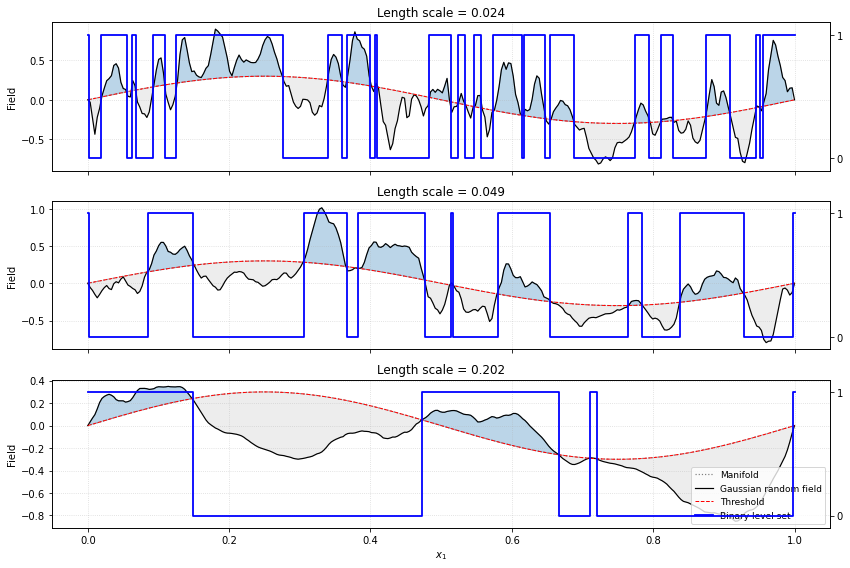

In [4]:
def plot_results(results, curve, display_fraction=0.5, savepath=None):
    fig, axes = plt.subplots(len(results), 1, figsize=(12, 8), sharex=True)
    if len(results) == 1:
        axes = [axes]

    x_coord = curve[:, 0]
    curve_y = curve[:, 1]

    curve_range = np.max(curve_y) - np.min(curve_y)
    if curve_range < 1e-9:
        curve_range = np.max(x_coord) - np.min(x_coord)
    display_amplitude = display_fraction * curve_range

    for i, (ax, ell_res) in enumerate(zip(axes, results)):
        ell, sample, field = ell_res["ell"], ell_res["sample"], ell_res["field"]

        display_sample = display_amplitude * sample
        field_y = curve_y + display_sample

        if i == 2:
            # Create labeled artists (only once)
            ax.plot([], [], color="gray", linestyle=":", lw=1.2, label="Manifold")
            ax.plot([], [], color="black", lw=1.2, label="Gaussian random field")
            ax.plot([], [], color="red", linestyle="--", lw=1, label="Threshold")
            ax2.step([], [], where="mid", color="blue", lw=1.8, label="Binary level set")

            lines_1, labels_1 = ax.get_legend_handles_labels()
            lines_2, labels_2 = ax2.get_legend_handles_labels()

            ax.legend(
                lines_1 + lines_2,
                labels_1 + labels_2,
                loc="lower right",
                fontsize=9
            )

        # --- Manifold baseline ---
        ax.plot(x_coord, curve_y, color="gray", linestyle=":", lw=1.2)

        # --- Plot GRF (lifted onto manifold) ---
        ax.plot(x_coord, field_y, color="black", lw=1.2)
        ax.plot(x_coord, curve_y, color="red", linestyle="--", lw=1)   # threshold = manifold itself

        # Filled regions
        ax.fill_between(
            x_coord, field_y, curve_y,
            where=(sample > 0),
            color="tab:blue", alpha=0.3
        )
        ax.fill_between(
            x_coord, field_y, curve_y,
            where=(sample <= 0),
            color="lightgray", alpha=0.4
        )

        # --- Binary overlay ---
        ax2 = ax.twinx()
        ax2.step(
            x_coord,
            field,
            where="mid",
            color="blue",
            lw=1.8
        )
        ax2.set_ylim(-0.1, 1.1)
        ax2.set_yticks([0, 1])

        # Styling
        ax.set_ylabel("Field")
        ax.set_title(f"Length scale = {ell:.3f}")
        ax.grid(True, linestyle=":", alpha=0.5)

    # Shared x-label
    axes[-1].set_xlabel("$x_1$")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

plot_results(results, curve, display_fraction=0.5, savepath="binary_level_sets_comparison.png")

In [8]:
from skfem import MeshTri, ElementTriP1
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection

nx_grid = 48
ny_grid = 48

xs = np.linspace(0, 1, nx_grid)
ys = np.linspace(0, 1, ny_grid)

mesh_param = MeshTri.init_tensor(xs, ys)   # planar (x,y) triangulation

# Use mesh_param's own (x,y) coordinates -- guaranteed consistent
# with F (connectivity) and with the FEM matrices / eigenvectors below
X, Y = mesh_param.p[0], mesh_param.p[1]
Z = 0.25 * np.sin(2*np.pi*X) * np.cos(2*np.pi*Y)   # evaluate height at mesh's own points

V = np.stack([X, Y, Z], axis=1)   # (n, 3) embedded coordinates, aligned with mesh_param.p
F = mesh_param.t.T                 # (n_faces, 3) triangle connectivity
n = len(V)

In [9]:
# FEM assembly
basis = Basis(mesh_param, ElementTriP1())
S_full = laplace.assemble(basis).toarray()
M_full = mass.assemble(basis).toarray()

# Boundary vertices -> Dirichlet BC
boundary_dofs = mesh_param.boundary_nodes()
interior_idx = np.setdiff1d(np.arange(n), boundary_dofs)

S_int = S_full[np.ix_(interior_idx, interior_idx)]
M_int = M_full[np.ix_(interior_idx, interior_idx)]

# Eigenbasis of the Laplace-Beltrami operator
n_modes = 150
lam, Veig = eigh(S_int, M_int, subset_by_index=[0, n_modes - 1])
lam = np.maximum(lam, 0)

# Sampler and level-set map
def sample_grf_spde_2d(kappa, alpha):
    std = (kappa**2 + lam) ** (-alpha / 2)
    z = np.random.randn(len(lam))
    m_int = Veig @ (std * z)

    marginal_var = np.sum((Veig * std[None, :])**2, axis=1)
    m_int *= 1.0 / np.sqrt(np.mean(marginal_var))

    m_full = np.zeros(n)
    m_full[interior_idx] = m_int
    return m_full

def level_set_map(sample, c, g):
    c_full = [-np.inf] + list(c) + [np.inf]
    result = np.zeros_like(sample, dtype=float)
    for i in range(len(g)):
        mask = (sample >= c_full[i]) & (sample < c_full[i+1])
        result[mask] = g[i]
    return result

def extract_level_set_edges(V, F, field, level=0.0):
    """Marching-triangles: trace the zero-crossing curve on the mesh."""
    segments = []
    for tri in F:
        vals = field[tri] - level
        pts = V[tri]
        crossings = []
        for a, b in [(0,1), (1,2), (2,0)]:
            va, vb = vals[a], vals[b]
            if va * vb < 0:
                t = va / (va - vb)
                crossings.append(pts[a] + t * (pts[b] - pts[a]))
        if len(crossings) == 2:
            segments.append(crossings)
    return segments

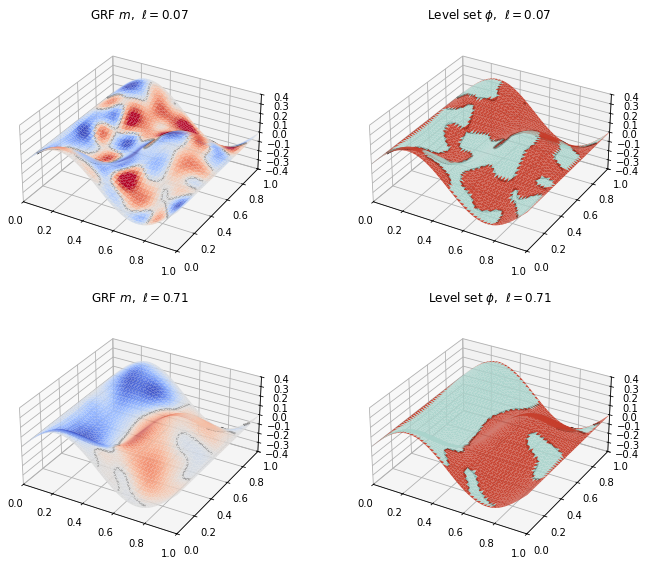

In [16]:
nu = 1.5
alpha = nu + 1.0     # = nu + (d-1)/2, d-1 = 2 for a surface
c_thresh, g_vals = [0.0], [0.0, 1.0]

domain_diag = np.sqrt(2)
length_scales = [0.05 * domain_diag, 0.5 * domain_diag]

fig = plt.figure(figsize=(11, 4 * len(length_scales)))

for i, ell in enumerate(length_scales):
    kappa  = np.sqrt(2 * nu) / ell
    sample = sample_grf_spde_2d(kappa, alpha)
    field  = level_set_map(sample, c_thresh, g_vals)
    edges  = extract_level_set_edges(V, F, sample, level=0.0)

    # --- Left: continuous GRF on the manifold ---
    ax1 = fig.add_subplot(len(length_scales), 2, 2*i + 1, projection='3d')
    face_vals = sample[F].mean(axis=1)
    vmax = np.percentile(np.abs(face_vals), 95)   # instead of np.max(np.abs(face_vals))
    norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    facecolors = cm.coolwarm(norm(face_vals))
    #face_vals = sample[F].mean(axis=1)
    #vmax = np.max(np.abs(face_vals))
    norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    facecolors = cm.coolwarm(norm(face_vals))

    ax1.add_collection3d(Poly3DCollection(V[F], facecolors=facecolors,
                                          edgecolor='none', alpha=1.0))
    if edges:
        ax1.add_collection3d(Line3DCollection(edges, colors='black', linewidths=2.0))

    ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.set_zlim(-0.4, 0.4)
    ax1.set_title(f"GRF $m$,  $\\ell={ell:.2f}$")
    ax1.set_box_aspect([1, 1, 0.5])

    # --- Right: binary level set on the manifold ---
    ax2 = fig.add_subplot(len(length_scales), 2, 2*i + 2, projection='3d')
    face_field = field[F].mean(axis=1)
    binary_colors = np.where(face_field[:, None] >= 0.5,
                             np.array([[0.777, 0.239, 0.164, 1.0]]),
                             np.array([[0.667, 0.831, 0.800, 1.0]]))
    ax2.add_collection3d(Poly3DCollection(V[F], facecolors=binary_colors,
                                          edgecolor='none', alpha=0.95))
    if edges:
        ax2.add_collection3d(Line3DCollection(edges, colors='black', linewidths=2.0))

    ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.set_zlim(-0.4, 0.4)
    ax2.set_title(f"Level set $\\phi$,  $\\ell={ell:.2f}$")
    ax2.set_box_aspect([1, 1, 0.5])

plt.tight_layout()
plt.savefig("binary_level_sets_2d_manifold.png", dpi=200, bbox_inches="tight")
plt.show()